# Lasso breakdown: fee update and weight change at each iteration

Same example portfolio as `light_strike_reduction.ipynb` (60 options, at most 8 positions, risk constraints on), with **one change to the algorithm: the non-negative constraint on the weights is removed.** A weight can now be negative, which means the reduced book is short that strike. The fee is charged on the size of the weight, `α · pen_j · |w_j|`.

This notebook follows the reweighting loop iteration by iteration:

- **Fee multiplier `pen_j`**: what each strike is charged per unit of weight. All fees are 1 at iteration 0, then after each iteration
  `pen_j = 1 / (|w_j| + 0.5 × mean of non-zero |w|)`.
- **Weight `w_j`**: the multiplier on the book quantity (1 = keep the position as it is, 0 = drop it, negative = short).

One iteration = take the fees, search α (30-point grid + 15-point refinement), keep the best fit with ≤ 8 positions, then update the fees from the weights found.

### Imports and helpers (same as `light_strike_reduction.ipynb`)

In [1]:
import warnings

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")


def bs(S, K, T, sigma, is_call):
    """Black-Scholes price and delta (r = 0)."""
    sd = sigma * np.sqrt(T)
    d1 = np.log(S / K) / sd + sd / 2
    call = S * norm.cdf(d1) - K * norm.cdf(d1 - sd)
    return np.where(is_call, call, call - S + K), norm.cdf(d1) - ~is_call


def unit_risk(K, is_call, S, T, sigma, shocks=(-0.05, -0.10)):
    """t0 risk of one unit of each option: gamma cash, theta (per day), vega (per vol point), delta hedged slides."""
    sd = sigma * np.sqrt(T)
    pdf = norm.pdf(np.log(S / K) / sd + sd / 2)
    price, delta = bs(S, K, T, sigma, is_call)
    risk = {"gamma_cash": pdf * S / sd / 100, "theta": -S * pdf * sigma / (2 * np.sqrt(T)) / 252, "vega": S * pdf * np.sqrt(T) / 100}
    for x in shocks:
        risk[f"slide_{x:+.0%}"] = bs(S * (1 + x), K, T, sigma, is_call)[0] - price - delta * S * x
    return pd.DataFrame(risk)


def _qr(X, y):
    """||y - X w||^2 = ||z - R w||^2 + const on scaled data, and the R2 of weights w."""
    s = np.sqrt(np.mean(y ** 2))
    q, R = np.linalg.qr(X.to_numpy() / s)
    ys = y.to_numpy() / s
    z = q.T @ ys
    sse_perp, sst = ys @ ys - z @ z, ((ys - ys.mean()) ** 2).sum()
    return R, z, lambda w: 1 - (((z - R @ w) ** 2).sum() + sse_perp) / sst


def _constraints(w, cols, risk, floors, bands):
    """reduced >= ratio * full for floors, |reduced - full| <= tol * |full| for bands (relative to |full|)."""
    full = risk.sum()
    rel = {m: risk.loc[cols, m].to_numpy() / abs(full[m]) @ w - np.sign(full[m]) for m in [*floors, *bands]}
    return ([rel[m] + (1 - k) * np.sign(full[m]) >= 0 for m, k in floors.items()]
            + [cp.abs(rel[m]) <= tol for m, tol in bands.items()])


def _solve(problem, w):
    """Solved weights with solver zeros cleaned, or None if infeasible."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            problem.solve(solver=cp.CLARABEL)
    except cp.SolverError:
        return None
    if problem.status not in ("optimal", "optimal_inaccurate"):
        return None
    w = w.value.copy()
    w[np.abs(w) < 1e-6 * np.abs(w).max()] = 0.0
    return w

### Example portfolio

In [2]:
S0, T, sigma = 100.0, 60 / 252, 0.20
strikes = np.linspace(75, 130, 60)
is_call = strikes >= S0
names = [f"{'call' if c else 'put'}_{k:.1f}" for k, c in zip(strikes, is_call)]
portfolio_weight = pd.Series(1e7 / strikes ** 2, index=names)

rng = np.random.default_rng(42)
spots = S0 * np.exp(sigma * np.sqrt(T) * rng.standard_normal(5_000) - sigma ** 2 * T / 2)
option_terminal_payoff = pd.DataFrame(np.where(is_call, np.maximum(spots[:, None] - strikes, 0), np.maximum(strikes - spots[:, None], 0)),
                                      index=spots, columns=names)
risk_t0 = unit_risk(strikes, is_call, S0, T, sigma).set_axis(names)
option_bid_offer = pd.Series(-0.01 * (strikes - S0) ** 2, index=names)

risk_floor, risk_tolerance, max_n, pnl_haircut = ["gamma_cash", "theta", "slide_-5%", "slide_-10%"], {"vega": 0.05}, 8, 0.8
floors = dict.fromkeys(risk_floor, 1.0) | {"bid_offer": pnl_haircut}

X = option_terminal_payoff[names] * portfolio_weight
y = X.sum(axis=1)
risk = risk_t0.assign(bid_offer=option_bid_offer).loc[names].mul(portfolio_weight, axis=0)

### Run the lasso and record every iteration

`lasso_iterations` follows `lasso()` and stores, for each iteration, the fees used, the α chosen and the weights found. The differences from `lasso()` that come from removing the non-negative constraint:

- `w` is a free variable (`cp.Variable(p)` instead of `nonneg=True`) and the fee is `pen @ cp.abs(w)`;
- a position is any non-zero weight, and `_solve` no longer clips negative weights to zero;
- `top` and the fee update use absolute values.

In [3]:
def lasso_iterations(X, y, risk, max_n, floors, bands, eps_scale=0.5, n_iter=10, n_grid=30, n_refine=15):
    """lasso() of light_strike_reduction.ipynb without the w >= 0 constraint, returning one row per iteration."""
    n, p = X.shape
    R, z, r2 = _qr(X, y)
    w, pen = cp.Variable(p), cp.Parameter(p, nonneg=True)  # weights are free to be negative (short)
    problem = cp.Problem(cp.Minimize(cp.sum_squares(R @ w - z) / (2 * n) + pen @ cp.abs(w)), _constraints(w, X.columns, risk, floors, bands))

    def fit(alpha, strike_pen):
        pen.value = alpha * strike_pen
        c = _solve(problem, w)
        return None if c is None else {"alpha": alpha, "n": int((c != 0).sum()), "r2": r2(c), "w": c}

    def fits(alphas, strike_pen):
        return [f for a in alphas if (f := fit(a, strike_pen))]

    def best_alpha(strike_pen):
        top = np.abs(R.T @ z / n / strike_pen).max()
        grid = fits(np.geomspace(top, top * 1e-4, n_grid), strike_pen)
        best = max([f for f in grid if f["n"] <= max_n] or [min(grid, key=lambda f: f["n"])], key=lambda f: f["r2"])
        if smaller := [f["alpha"] for f in grid if f["alpha"] < best["alpha"]]:
            refined = fits(np.geomspace(best["alpha"], smaller[0], n_refine), strike_pen)
            best = max([best, *[f for f in refined if f["n"] <= max_n]], key=lambda f: f["r2"])
        return best

    strike_pen, rows = np.ones(p), []
    for it in range(n_iter):
        f = best_alpha(strike_pen)
        rows.append({"alpha": f["alpha"], "n": f["n"], "r2": f["r2"], "pen": strike_pen.copy(), "w": f["w"]})
        a = np.abs(f["w"])
        strike_pen = 1 / (a + eps_scale * a[a > 0].mean())
    return pd.DataFrame(rows).rename_axis("iteration")


iters = lasso_iterations(X, y, risk, max_n, floors, risk_tolerance)
PEN = pd.DataFrame(np.vstack(iters["pen"]), index=iters.index, columns=names)  # fees used by each iteration
W = pd.DataFrame(np.vstack(iters["w"]), index=iters.index, columns=names)      # weights found by each iteration
dW = W.diff().fillna(W.iloc[[0]])                                              # weight change vs previous iteration
dPEN = PEN.diff()                                                              # fee update vs previous iteration

summary = iters[["alpha", "n", "r2"]].assign(
    mean_abs_weight=W.abs().where(W != 0).mean(axis=1),
    n_short=(W < 0).sum(axis=1),
    dropped_fee=PEN.max(axis=1),
    lowest_fee=PEN.min(axis=1),
    entered=[", ".join(W.columns[(W.loc[i] != 0) & ((W.loc[i - 1] == 0) if i else True)]) for i in W.index],
    dropped=[", ".join(W.columns[(W.loc[i] == 0) & (W.loc[i - 1] != 0)]) if i else "" for i in W.index])
with pd.option_context("display.max_colwidth", None, "display.float_format", lambda v: f"{v:.4g}"):
    display(summary)

,alpha,n,r2,mean_abs_weight,n_short,dropped_fee,lowest_fee,entered,dropped
iteration,,,,,,,,,
0,0.004192,8,0.9495,3.85,0,1,1,"put_90.8, put_91.8, put_92.7, put_93.6, put_94.6, call_103.0, call_103.9, call_104.8",
1,0.00108,8,0.9865,4.818,0,0.5195,0.08941,"put_84.3, put_85.3, put_99.2, call_113.2","put_92.7, put_93.6, call_103.0, call_104.8"
2,0.0003162,8,0.9965,5.622,0,0.4151,0.07482,"call_100.2, call_119.7","put_85.3, put_90.8"
3,0.0002524,8,0.9976,5.915,0,0.3558,0.06291,,
4,0.0002651,8,0.9979,6.078,0,0.3381,0.06878,,
5,0.0002809,8,0.998,6.118,0,0.3291,0.07341,,
6,0.0002847,8,0.998,6.127,0,0.3269,0.07332,,
7,0.0002857,8,0.998,6.128,0,0.3264,0.07331,,
8,0.0002859,8,0.998,6.129,0,0.3264,0.07331,,


**How to read the table:** `dropped_fee` is the fee multiplier charged to every strike that had zero weight in the previous iteration (`1 / (0.5 × mean weight)`), and `lowest_fee` is the fee of the largest position. `entered` and `dropped` list the strikes whose weight went from zero to positive, or from positive to zero, compared with the previous iteration.

## 1. Iteration by iteration

One row of three charts per iteration:

- **Left: fees going in.** The fee multiplier of each strike for this iteration (coloured), with the previous iteration's fees as a grey line. Low bar = cheap to hold.
- **Middle: weights coming out.** The weights found with those fees (coloured), with the previous iteration's weights as grey outlines.
- **Right: weight change.** This iteration's weight minus the previous one. Green = increased or entered, red = decreased or dropped.

Blue is puts and orange is calls. Bars below zero are short positions.

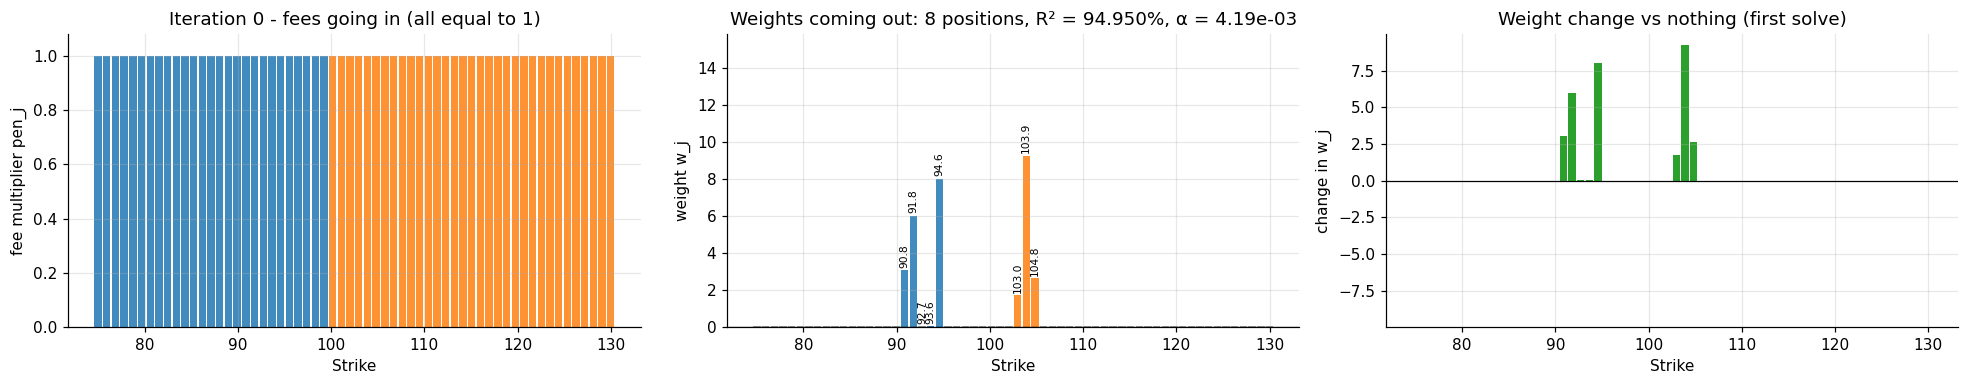

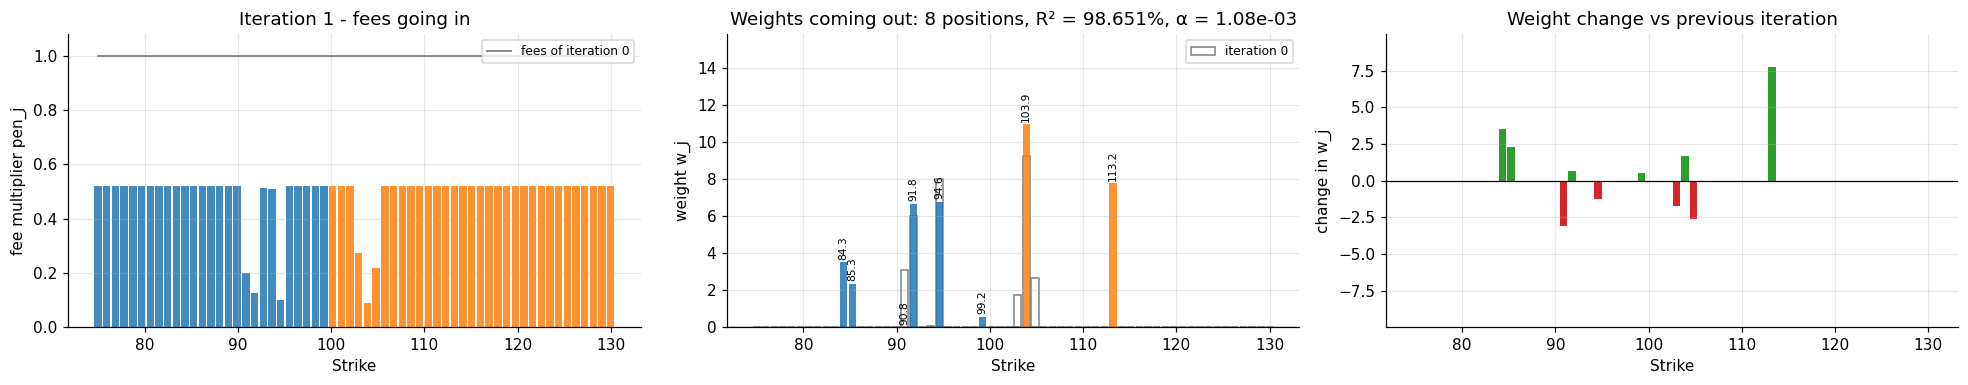

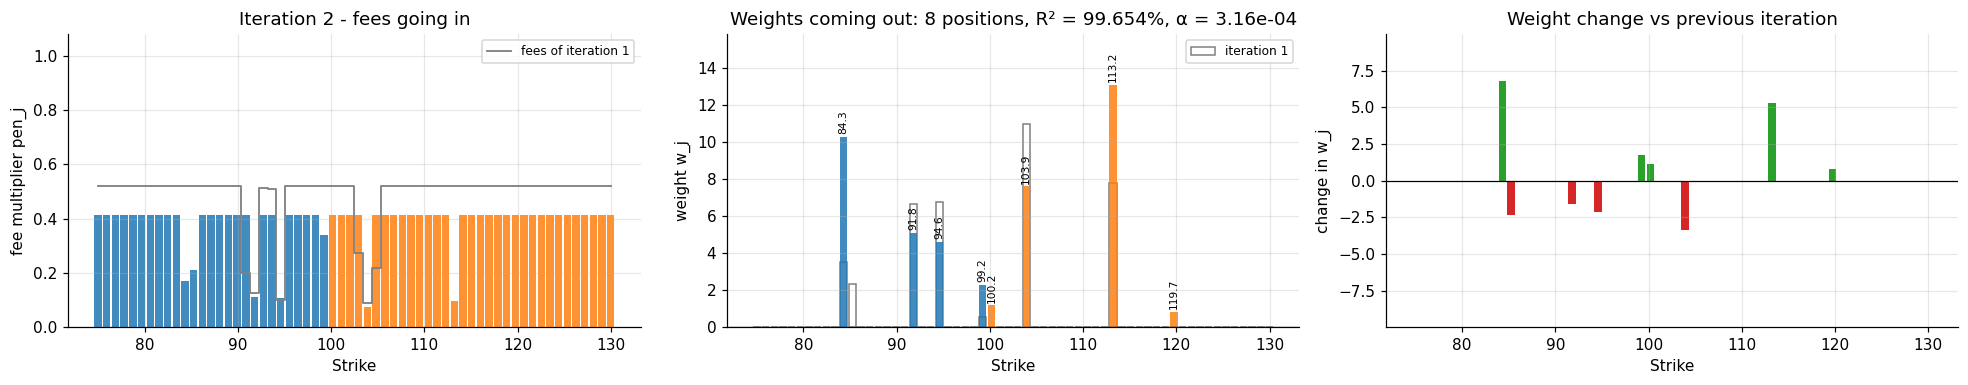

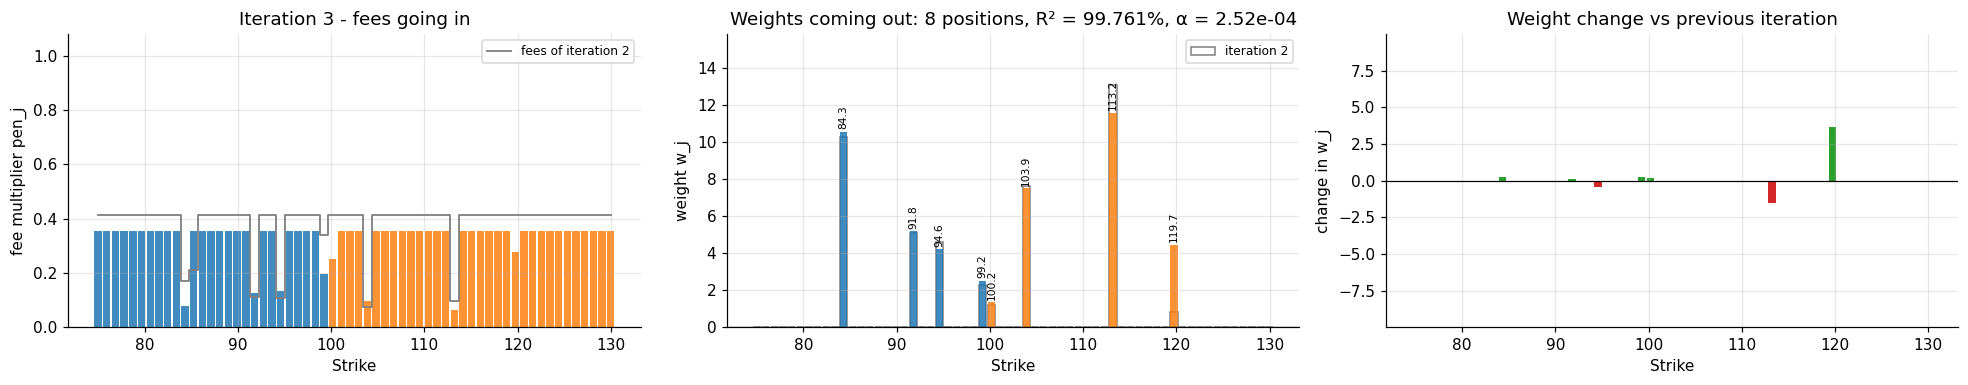

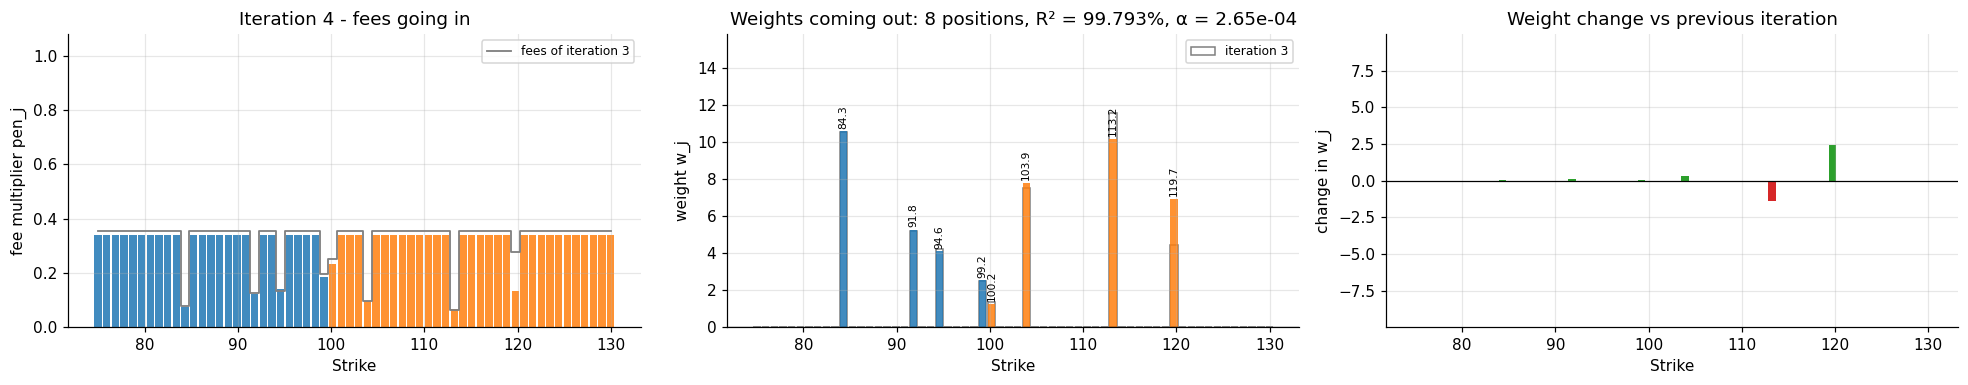

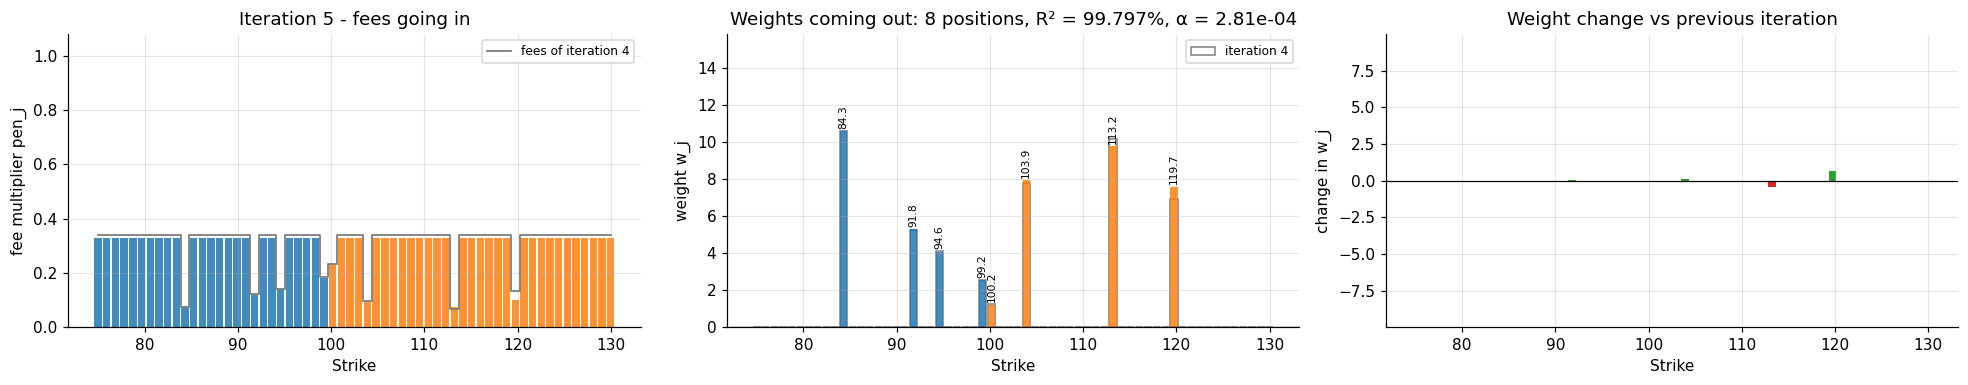

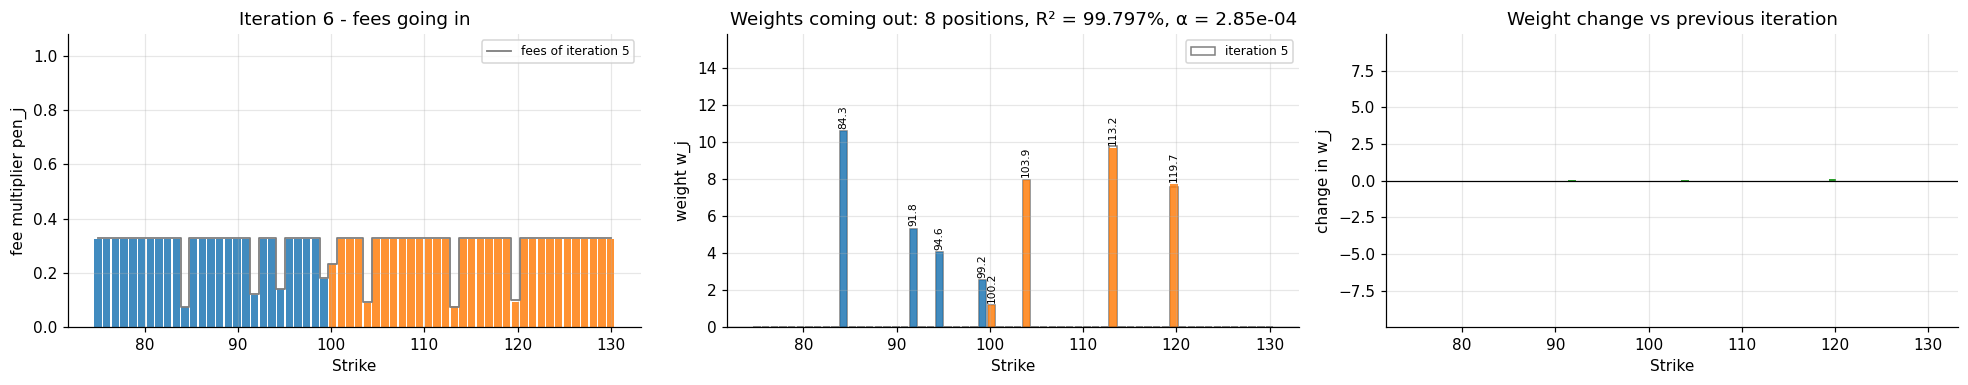

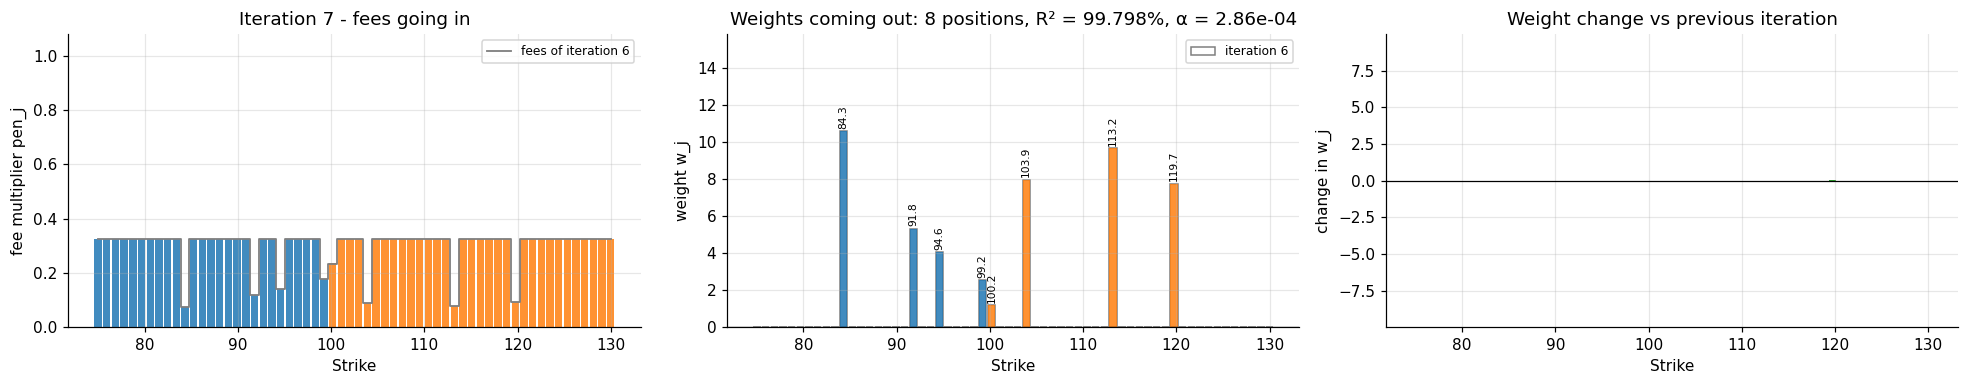

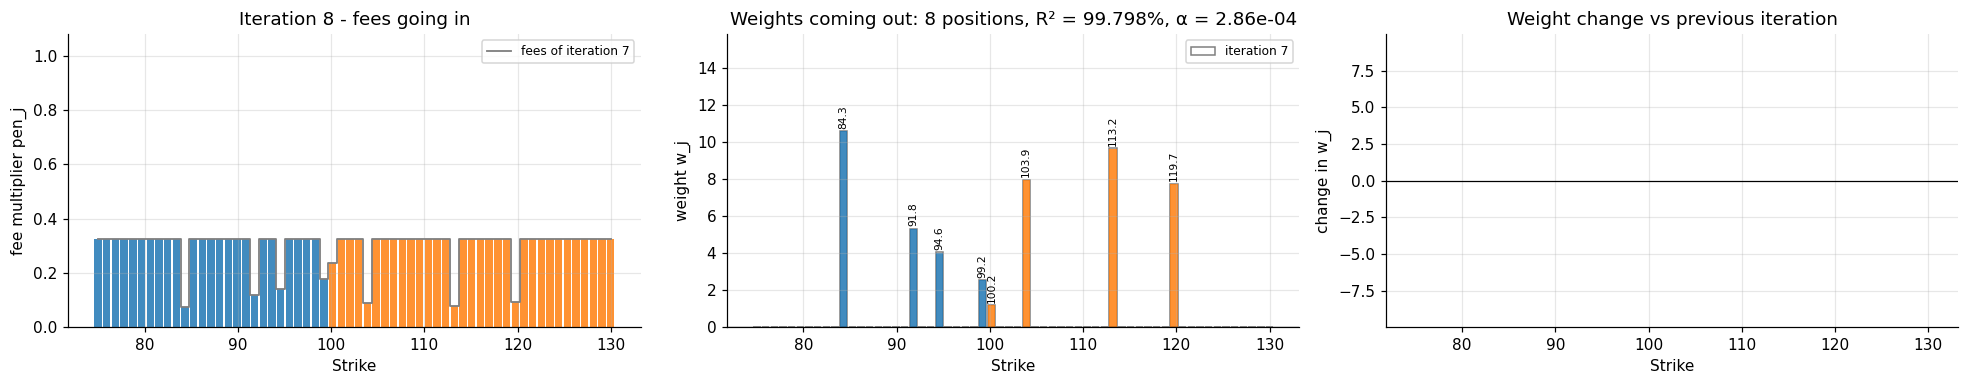

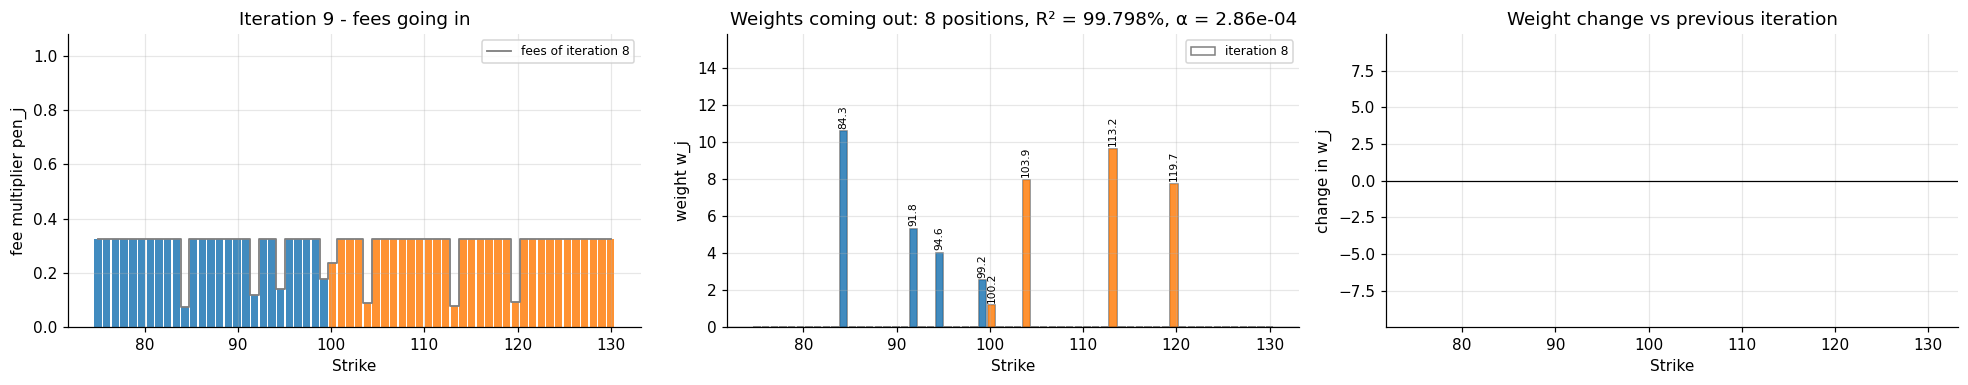

In [4]:
bar_w = (strikes[1] - strikes[0]) * 0.85
col = np.where(is_call, "tab:orange", "tab:blue")
w_max, w_min, dw_max = W.to_numpy().max() * 1.08, min(W.to_numpy().min() * 1.08, 0), np.abs(dW.to_numpy()).max() * 1.08

for it in iters.index:
    w_now, pen_now = W.loc[it].to_numpy(), PEN.loc[it].to_numpy()
    w_prev = W.loc[it - 1].to_numpy() if it else np.zeros(len(strikes))
    change = w_now - w_prev
    fig, axes = plt.subplots(1, 3, figsize=(18, 3.6))

    axes[0].bar(strikes, pen_now, width=bar_w, color=col, alpha=0.85)
    if it:
        axes[0].step(strikes, PEN.loc[it - 1], where="mid", color="grey", lw=1.2, label=f"fees of iteration {it - 1}")
        axes[0].legend(fontsize=8, loc="upper right")
    axes[0].set(xlabel="Strike", ylabel="fee multiplier pen_j", ylim=(0, 1.08),
                title=f"Iteration {it} - fees going in" + (" (all equal to 1)" if it == 0 else ""))

    axes[1].bar(strikes, w_prev, width=bar_w, facecolor="none", edgecolor="grey", lw=1, label=f"iteration {it - 1}" if it else None)
    axes[1].bar(strikes, w_now, width=bar_w, color=col, alpha=0.85)
    for k, v in zip(strikes[w_now != 0], w_now[w_now != 0]):
        axes[1].text(k, max(v, 0) + w_max * 0.01, f"{k:.1f}", ha="center", va="bottom", fontsize=7, rotation=90)
    axes[1].axhline(0, color="k", lw=0.8)
    if it:
        axes[1].legend(fontsize=8, loc="upper right")
    axes[1].set(xlabel="Strike", ylabel="weight w_j", ylim=(w_min * 1.12, w_max * 1.12),
                title=f"Weights coming out: {iters.loc[it, 'n']} positions, R² = {iters.loc[it, 'r2']:.3%}, α = {iters.loc[it, 'alpha']:.2e}")

    axes[2].bar(strikes, change, width=bar_w, color=np.where(change >= 0, "tab:green", "tab:red"))
    axes[2].axhline(0, color="k", lw=0.8)
    axes[2].set(xlabel="Strike", ylabel="change in w_j", ylim=(-dw_max, dw_max),
                title="Weight change vs previous iteration" if it else "Weight change vs nothing (first solve)")
    plt.tight_layout()
    plt.show()

## 2. Fee update after each iteration

After iteration `i` the weights `w` are turned into the fees of iteration `i + 1`:

`pen_j = 1 / (|w_j| + 0.5 × mean of non-zero |w|)`

Each chart below shows one update: the fees before (grey line), the fees after (bars), for every strike. Strikes with weight get a fee well below the rest, and the larger the weight the lower the fee. All strikes with zero weight share the same fee, `1 / (0.5 × mean)`, shown as the dashed line.

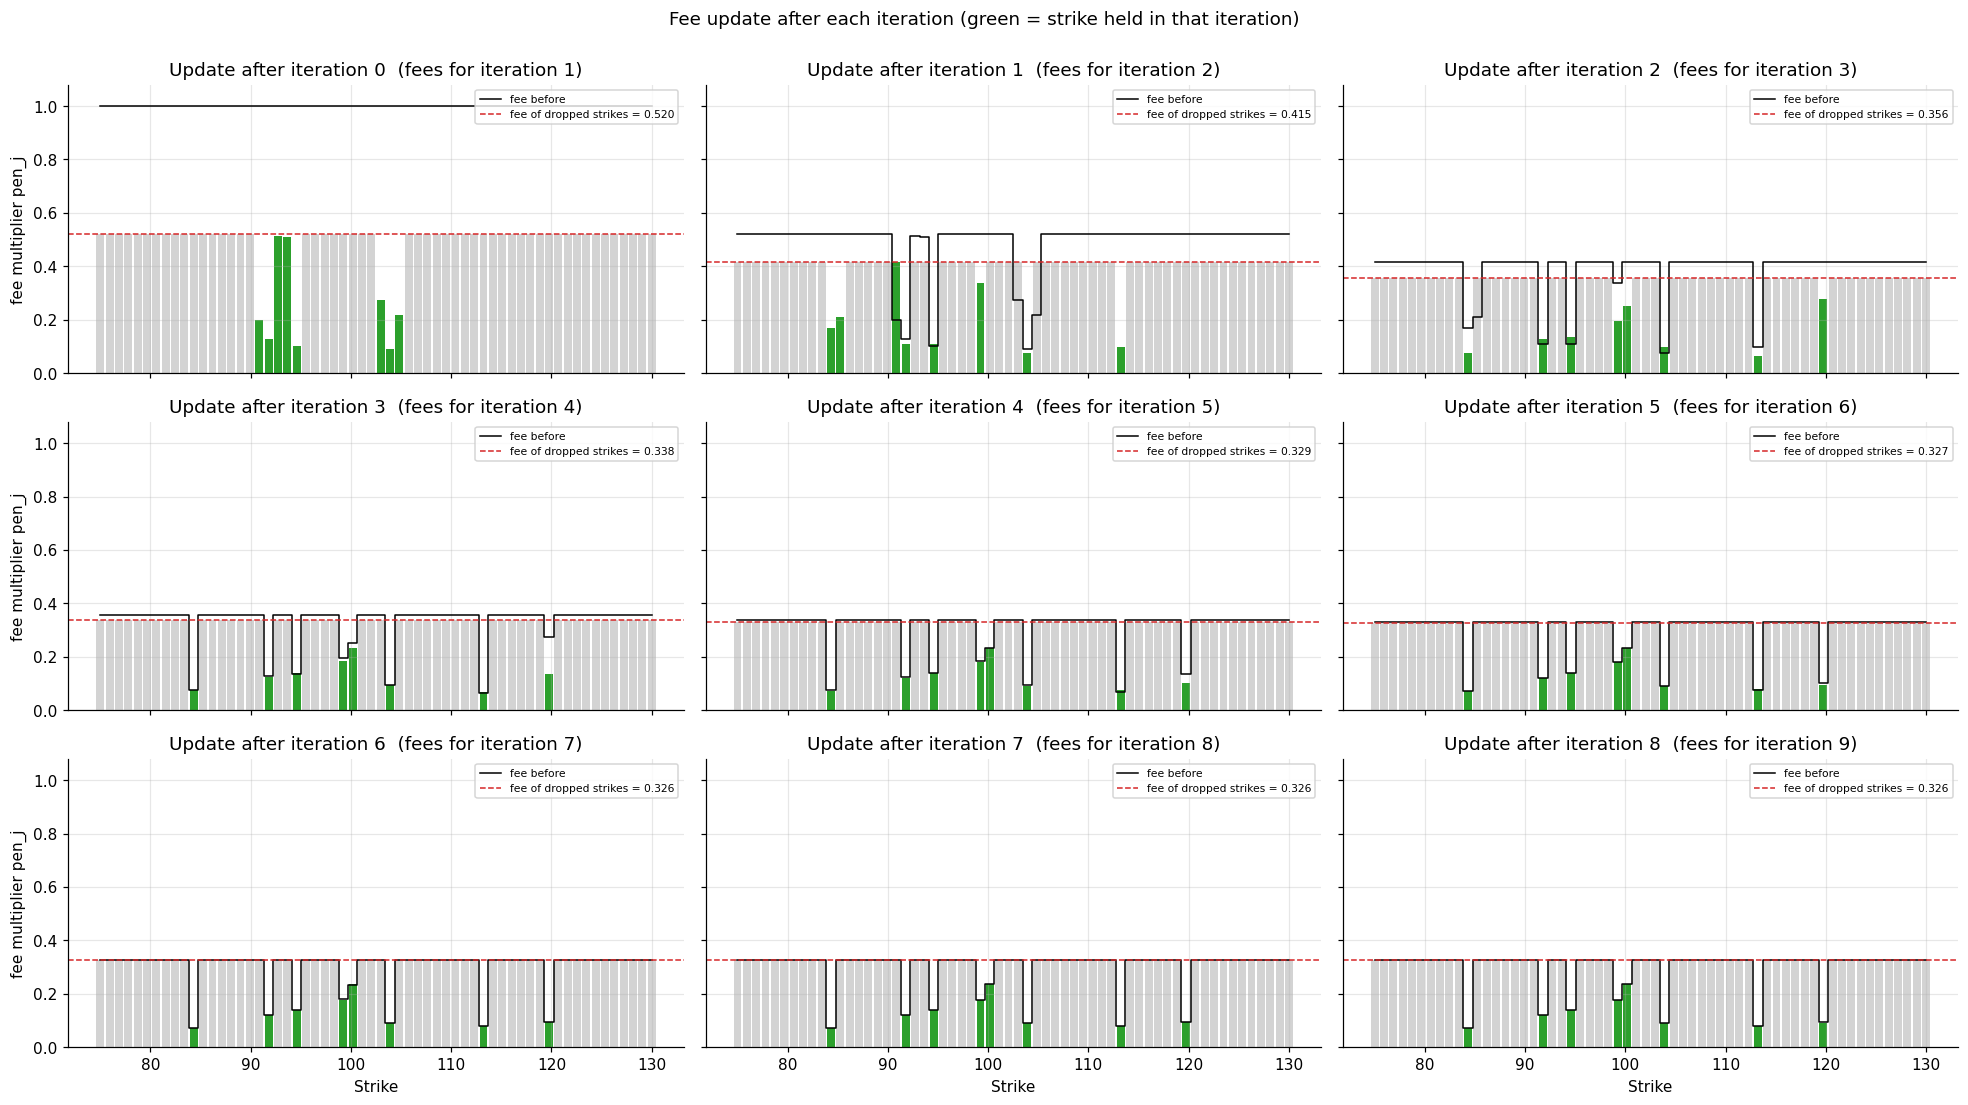

In [5]:
n_upd = len(iters) - 1
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True, sharey=True)
for it, ax in zip(range(n_upd), axes.ravel()):
    before, after, w_it = PEN.loc[it].to_numpy(), PEN.loc[it + 1].to_numpy(), W.loc[it].to_numpy()
    ax.bar(strikes, after, width=bar_w, color=np.where(w_it != 0, "tab:green", "lightgrey"))
    ax.step(strikes, before, where="mid", color="k", lw=1, label="fee before")
    ax.axhline(after.max(), color="tab:red", ls="--", lw=1, label=f"fee of dropped strikes = {after.max():.3f}")
    ax.set(title=f"Update after iteration {it}  (fees for iteration {it + 1})", ylim=(0, 1.08))
    ax.legend(fontsize=7, loc="upper right")
for ax in axes[-1]:
    ax.set_xlabel("Strike")
for ax in axes[:, 0]:
    ax.set_ylabel("fee multiplier pen_j")
fig.suptitle("Fee update after each iteration (green = strike held in that iteration)", y=1.0)
plt.tight_layout()
plt.show()

## 3. All iterations in one view

- **Top row:** the fee and the weight of every strike that was ever selected, followed across iterations. Thick lines are the 8 strikes in the final answer.
- **Bottom row:** heatmaps by strike and iteration of the fee update (change in `pen_j`) and of the weight change.

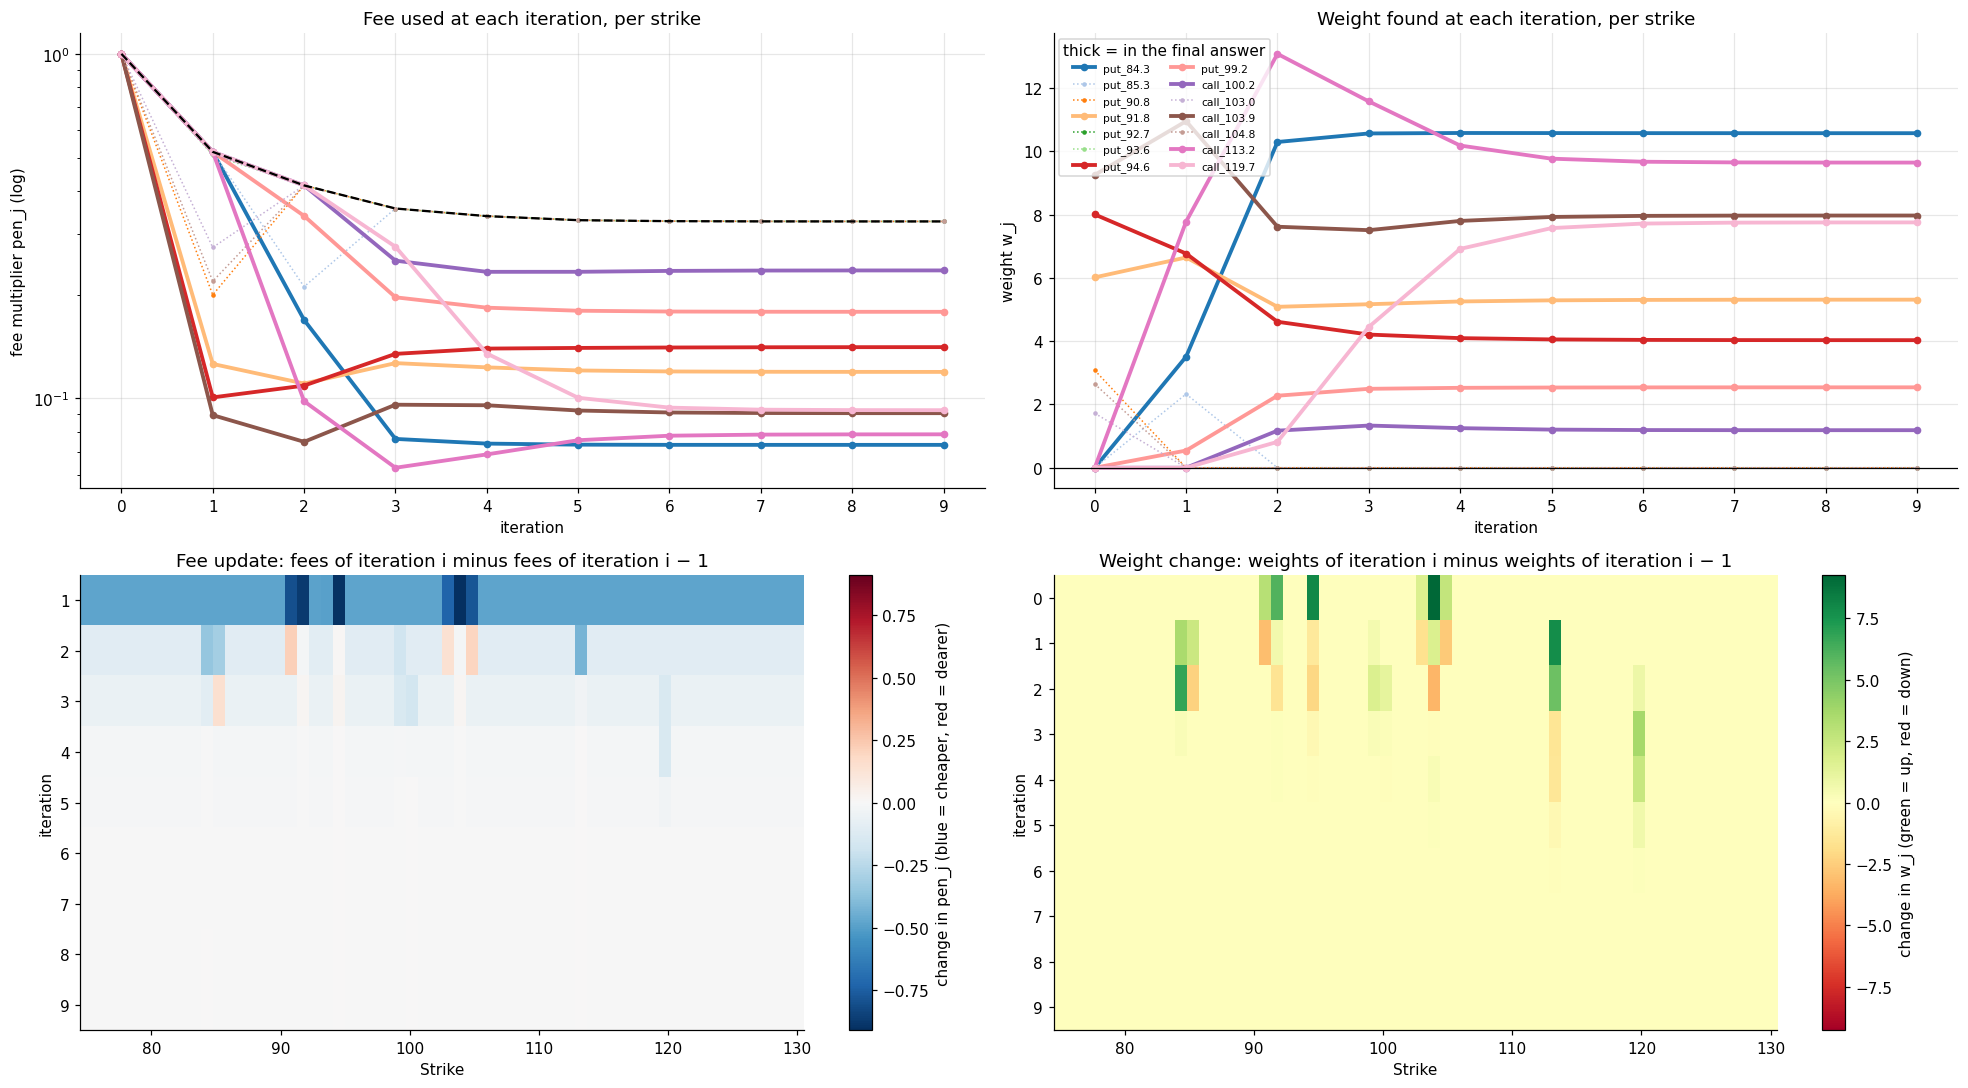

In [6]:
ever = W.columns[(W != 0).any()]
final = W.columns[W.iloc[-1] != 0]
cmap = plt.get_cmap("tab20")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i, c in enumerate(ever):
    style = dict(color=cmap(i % 20), lw=2.5 if c in final else 1, ls="-" if c in final else ":", marker="o", ms=4 if c in final else 2)
    axes[0, 0].plot(PEN.index, PEN[c], **style, label=c)
    axes[0, 1].plot(W.index, W[c], **style, label=c)
axes[0, 0].plot(PEN.index, PEN.max(axis=1), "k--", lw=1.5, label="dropped strikes")
axes[0, 0].set(yscale="log", xlabel="iteration", ylabel="fee multiplier pen_j (log)", title="Fee used at each iteration, per strike", xticks=PEN.index)
axes[0, 1].axhline(0, color="k", lw=0.8)
axes[0, 1].set(xlabel="iteration", ylabel="weight w_j", title="Weight found at each iteration, per strike", xticks=W.index)
axes[0, 1].legend(fontsize=7, ncol=2, title="thick = in the final answer")

ext = [strikes[0] - 0.5, strikes[-1] + 0.5, len(iters) - 0.5, 0.5]
lim = np.nanmax(np.abs(dPEN.iloc[1:].to_numpy()))
im = axes[1, 0].imshow(dPEN.iloc[1:], aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim, extent=ext)
plt.colorbar(im, ax=axes[1, 0], label="change in pen_j (blue = cheaper, red = dearer)")
axes[1, 0].set(xlabel="Strike", ylabel="iteration", title="Fee update: fees of iteration i minus fees of iteration i − 1", yticks=range(1, len(iters)))
ext = [strikes[0] - 0.5, strikes[-1] + 0.5, len(iters) - 0.5, -0.5]
lim = np.abs(dW.to_numpy()).max()
im = axes[1, 1].imshow(dW, aspect="auto", cmap="RdYlGn", vmin=-lim, vmax=lim, extent=ext)
plt.colorbar(im, ax=axes[1, 1], label="change in w_j (green = up, red = down)")
axes[1, 1].set(xlabel="Strike", ylabel="iteration", title="Weight change: weights of iteration i minus weights of iteration i − 1", yticks=range(len(iters)))
for ax in axes[1]:
    ax.grid(False)
plt.tight_layout()
plt.show()

## 4. Convergence

How much the fees and weights still move at each iteration, next to the fit. When the bars reach zero the loop has converged and further iterations repeat the same answer.

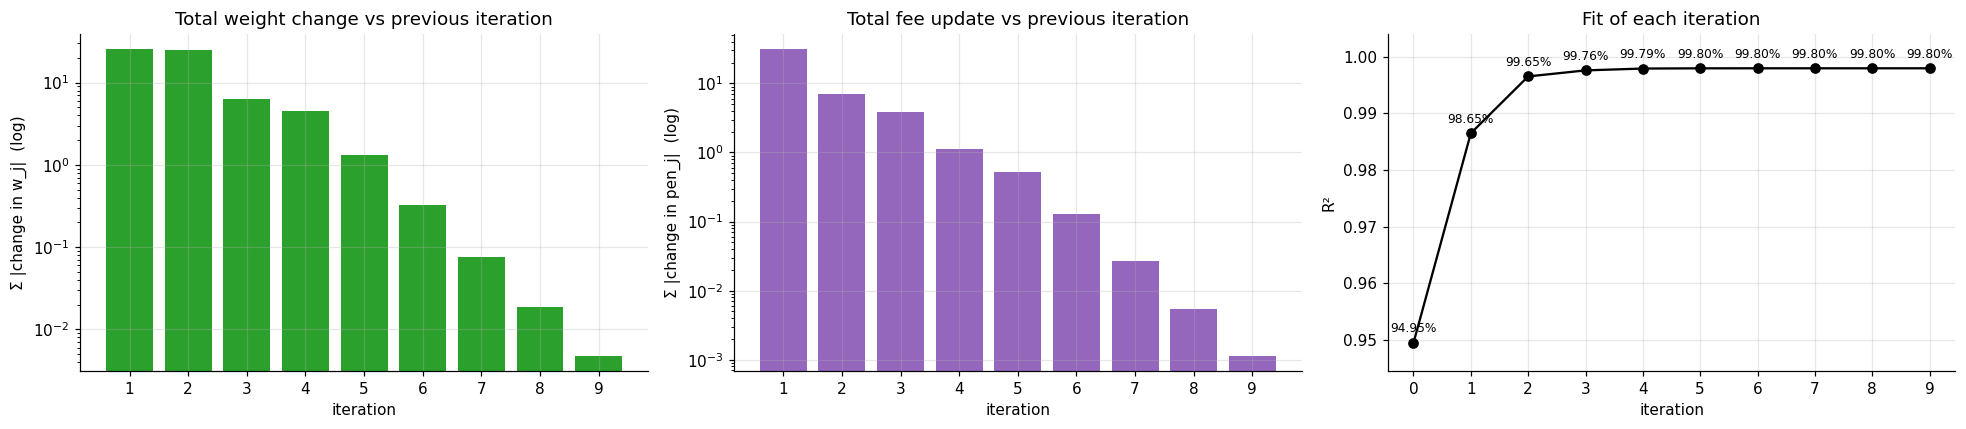

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(dW.index[1:], dW.iloc[1:].abs().sum(axis=1), color="tab:green")
axes[0].set(yscale="log", xlabel="iteration", ylabel="Σ |change in w_j|  (log)", title="Total weight change vs previous iteration", xticks=dW.index[1:])
axes[1].bar(dPEN.index[1:], dPEN.iloc[1:].abs().sum(axis=1), color="tab:purple")
axes[1].set(yscale="log", xlabel="iteration", ylabel="Σ |change in pen_j|  (log)", title="Total fee update vs previous iteration", xticks=dPEN.index[1:])
axes[2].plot(iters.index, iters["r2"], "o-", color="k")
for i, v in iters["r2"].items():
    axes[2].annotate(f"{v:.2%}", (i, v), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
axes[2].set(xlabel="iteration", ylabel="R²", title="Fit of each iteration", xticks=iters.index, ylim=(iters["r2"].min() - 0.005, 1.004))
plt.tight_layout()
plt.show()

### Tables: fees and weights of every strike that was ever selected

In [8]:
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print("Fee multiplier pen_j used at each iteration")
    display(PEN[ever].T.rename_axis("strike"))
    print("Weight w_j found at each iteration (0 = not held)")
    display(W[ever].T.rename_axis("strike"))
    print("Final quantities (book quantity × final weight)")
best_it = iters[iters["n"] <= max_n]["r2"].idxmax()
display((portfolio_weight * W.loc[best_it])[W.loc[best_it] != 0].to_frame(f"quantity (iteration {best_it})"))

Fee multiplier pen_j used at each iteration


iteration,0,1,2,3,4,5,6,7,8,9
strike,,,,,,,,,,
put_84.3,1.000,0.520,0.169,0.076,0.074,0.073,0.073,0.073,0.073,0.073
put_85.3,1.000,0.520,0.211,0.356,0.338,0.329,0.327,0.326,0.326,0.326
put_90.8,1.000,0.200,0.415,0.356,0.338,0.329,0.327,0.326,0.326,0.326
put_91.8,1.000,0.126,0.110,0.127,0.123,0.121,0.120,0.119,0.119,0.119
put_92.7,1.000,0.513,0.415,0.356,0.338,0.329,0.327,0.326,0.326,0.326
put_93.6,1.000,0.508,0.415,0.356,0.338,0.329,0.327,0.326,0.326,0.326
put_94.6,1.000,0.101,0.109,0.135,0.140,0.140,0.141,0.141,0.141,0.141
put_99.2,1.000,0.520,0.339,0.197,0.183,0.180,0.179,0.178,0.178,0.178
call_100.2,1.000,0.520,0.415,0.251,0.233,0.233,0.234,0.235,0.235,0.235


Weight w_j found at each iteration (0 = not held)


iteration,0,1,2,3,4,5,6,7,8,9
strike,,,,,,,,,,
put_84.3,0.000,3.511,10.298,10.568,10.583,10.580,10.578,10.577,10.577,10.576
put_85.3,0.000,2.331,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
put_90.8,3.080,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
put_91.8,6.018,6.648,5.088,5.169,5.257,5.292,5.306,5.311,5.313,5.314
put_92.7,0.023,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
put_93.6,0.042,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
put_94.6,8.008,6.771,4.615,4.210,4.097,4.057,4.042,4.036,4.034,4.033
put_99.2,0.000,0.544,2.277,2.496,2.527,2.536,2.540,2.542,2.542,2.542
call_100.2,0.000,0.000,1.172,1.334,1.252,1.206,1.192,1.188,1.187,1.187


Final quantities (book quantity × final weight)


,quantity (iteration 9)
put_84.3,14_875
put_91.8,6_308
put_94.6,4_509
put_99.2,2_582
call_100.2,1_183
call_103.9,7_386
call_113.2,7_526
call_119.7,5_409
